# 02 Baseline MLP

??????? MLP, ????????? ?? supervised ?????? FDM (??? PDE-loss).

In [3]:
import numpy as np
import torch
from torch import optim
from src.modeling import MLP, train_model, mlp_supervised_loss, save_model_weights
from src.utils import plot_loss_curves, plot_comparison

In [4]:
data = np.load('data/processed/pinn_dataset.npz')
xx, yy, field = data['fdm_xx'], data['fdm_yy'], data['fdm_field_norm']
inputs = np.column_stack([xx.ravel(), yy.ravel(), np.ones(xx.size)])
targets = field.reshape(-1, 1)
X = torch.tensor(inputs, dtype=torch.float32)
y = torch.tensor(targets, dtype=torch.float32)

[  200] loss=1.133836e-02
[  400] loss=3.687013e-03
[  600] loss=2.877263e-03
[  800] loss=2.255640e-03
[ 1000] loss=1.943216e-03


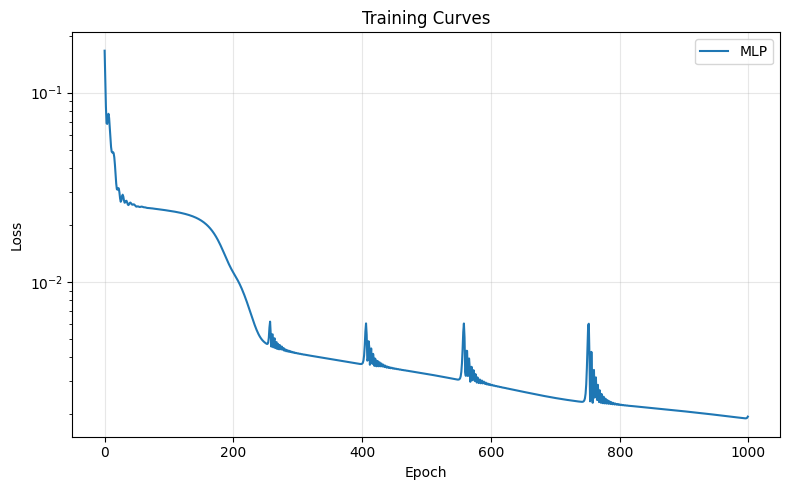

In [5]:
model = MLP(input_dim=3, hidden_dim=64, num_hidden_layers=4)
opt = optim.Adam(model.parameters(), lr=1e-3)

def loss_fn():
    return mlp_supervised_loss(model, X, y)

history = train_model(model, loss_fn, opt, epochs=1000, log_every=200)
plot_loss_curves([history], ['MLP'])

In [10]:
weights_path = save_model_weights(model, 'models/mlp_baseline.pt')
print('saved:', weights_path)

import os
print(os.getcwd())

saved: models\mlp_baseline.pt
C:\Users\nasty


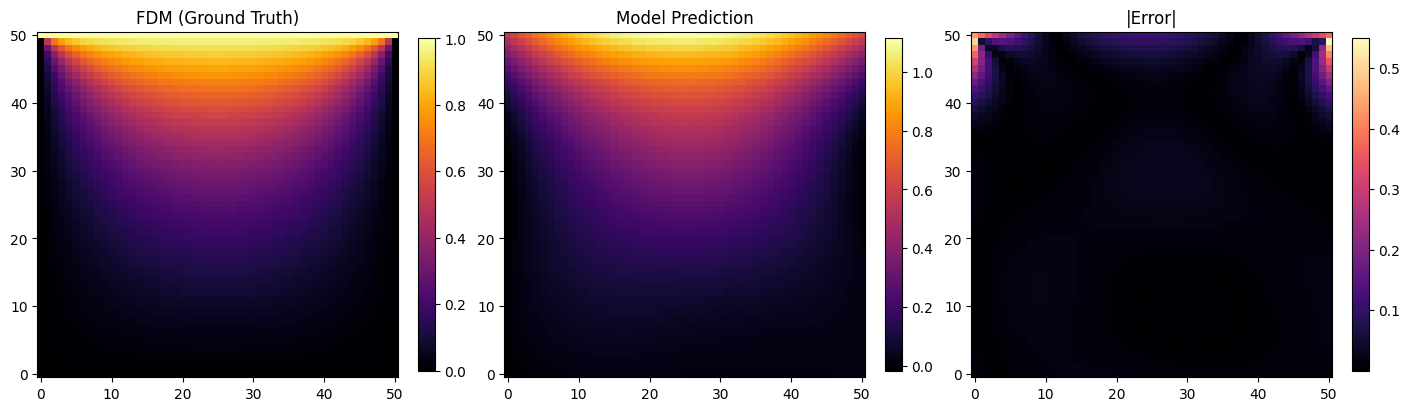

In [7]:
with torch.no_grad():
    pred = model(X).reshape(field.shape).cpu().numpy()
plot_comparison(field, pred)